# Monte Carlo Option Pricing

Monte Carlo simulation prices derivatives by averaging discounted payoffs over many risk-neutral paths. Its power lies in flexibility: any payoff function, any process, any number of assets. The cost is statistical noise, which shrinks at rate 1/√N.

| Method | Std Dev vs Naive | Notes |
|--------|------------------|-------|
| Naive MC | 1× | Baseline |
| Antithetic variates | ~0.73× | Pairs (Z, −Z) |
| Control variate | ~0.60× | Beta-adjusted stock price |

---

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from src.black_scholes import bs_price
from src.monte_carlo import (
    simulate_gbm_paths, mc_european, mc_antithetic,
    mc_control_variate, mc_asian, mc_barrier_down_out
)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20
bs_call = bs_price(S, K, T, r, sigma, 'call')
print(f'Black-Scholes reference call price: {bs_call:.4f}')

Black-Scholes reference call price: 10.4506


## Step 1 — GBM Path Visualisation

Under the risk-neutral measure, the stock price follows:

> **S_T = S₀ · exp((r − σ²/2)T + σ√T · Z)**

Each fan of paths represents a possible future scenario. The distribution of terminal prices S_T is log-normal, centred slightly above S₀ due to the risk-free drift r.

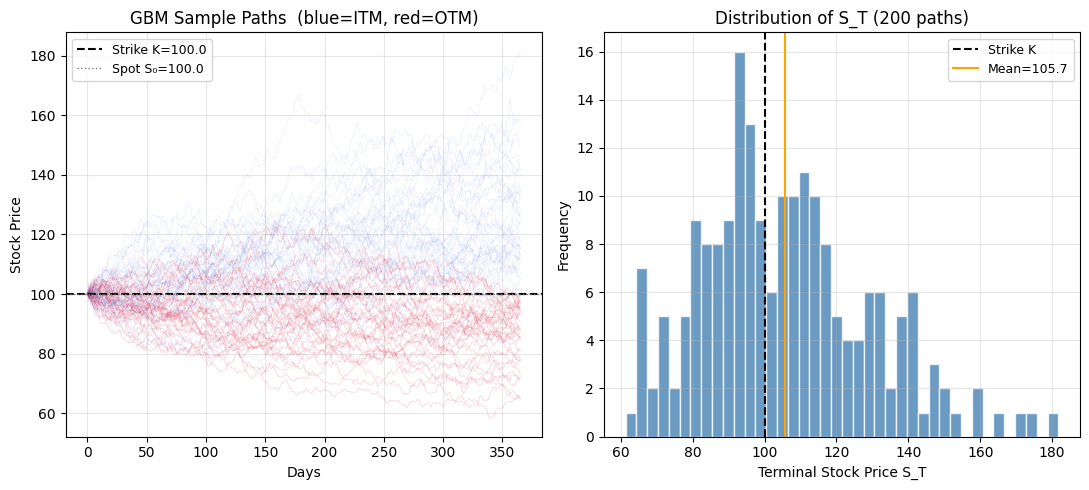

Theoretical E[S_T] = S·e^(rT) = 105.13
Sample mean of S_T = 105.73


In [2]:
paths = simulate_gbm_paths(S, T, r, sigma, n_sims=200, n_steps=252, seed=0)
t_axis = np.linspace(0, T * 365, 253)

fig, axes = plt.subplots(1, 2)
for i in range(min(80, paths.shape[0])):
    alpha = 0.08 if paths[i, -1] > K else 0.15
    col   = 'royalblue' if paths[i, -1] > K else 'crimson'
    axes[0].plot(t_axis, paths[i], color=col, alpha=alpha, lw=0.7)
axes[0].axhline(K,  color='black', lw=1.5, linestyle='--', label=f'Strike K={K}')
axes[0].axhline(S,  color='gray',  lw=1,   linestyle=':',  label=f'Spot S₀={S}')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Stock Price')
axes[0].set_title('GBM Sample Paths  (blue=ITM, red=OTM)')
axes[0].legend(fontsize=9)

terminal = paths[:, -1]
axes[1].hist(terminal, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(K,  color='black', lw=1.5, linestyle='--', label='Strike K')
axes[1].axvline(np.mean(terminal), color='orange', lw=1.5, label=f'Mean={np.mean(terminal):.1f}')
axes[1].set_xlabel('Terminal Stock Price S_T')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of S_T (200 paths)')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Theoretical E[S_T] = S·e^(rT) = {S * np.exp(r*T):.2f}')
print(f'Sample mean of S_T = {np.mean(terminal):.2f}')

## Step 2 — MC Convergence: Error vs Number of Paths

The standard error of a Monte Carlo estimate scales as σ/√N. This plot shows the absolute error |MC_price − BS_price| as a function of N, confirming the 1/√N convergence rate. On a log-log plot, this appears as a straight line with slope −½.

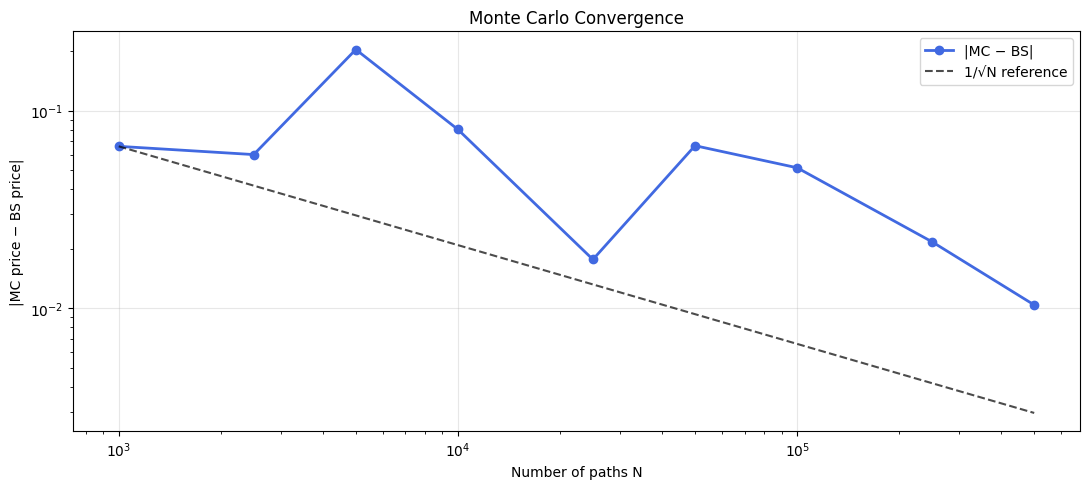

MC price at 500k paths: 10.4402
Black-Scholes price:    10.4506


In [3]:
n_sim_values = [1_000, 2_500, 5_000, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000]
errors = []
for n in n_sim_values:
    mc_p = mc_european(S, K, T, r, sigma, 'call', n_sims=n, seed=99)
    errors.append(abs(mc_p - bs_call))

fig, ax = plt.subplots()
ax.loglog(n_sim_values, errors, 'o-', color='royalblue', lw=2, label='|MC − BS|')
# Reference 1/sqrt(N) line
ref = errors[0] * np.sqrt(n_sim_values[0]) / np.sqrt(np.array(n_sim_values))
ax.loglog(n_sim_values, ref, 'k--', lw=1.5, alpha=0.7, label='1/√N reference')
ax.set_xlabel('Number of paths N')
ax.set_ylabel('|MC price − BS price|')
ax.set_title('Monte Carlo Convergence')
ax.legend()
plt.tight_layout()
plt.show()
print(f'MC price at 500k paths: {mc_european(S, K, T, r, sigma, n_sims=500_000, seed=99):.4f}')
print(f'Black-Scholes price:    {bs_call:.4f}')

## Step 3 — Variance Reduction: Antithetic & Control Variate

Both techniques produce the correct answer with fewer paths. We measure effectiveness by running 30 independent trials and comparing the **standard deviation across trials** — a direct measure of estimator variance.

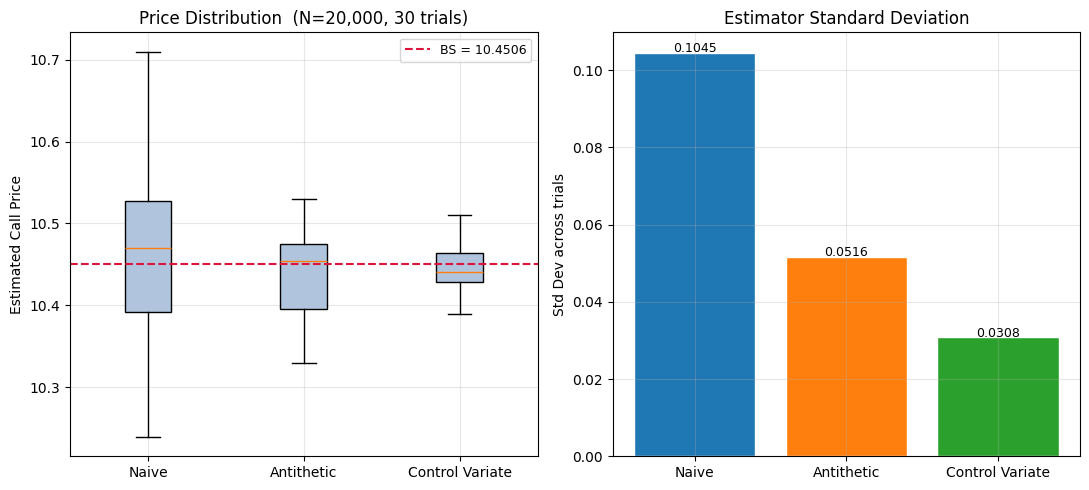

Antithetic std / Naive std = 0.49  (reduction: 51%)
Control var std / Naive std = 0.30  (reduction: 70%)


In [4]:
n_trials = 30
n_sims   = 20_000
naive_prices, anti_prices, cv_prices = [], [], []

for seed in range(n_trials):
    naive_prices.append(mc_european(S, K, T, r, sigma, n_sims=n_sims, seed=seed))
    anti_prices.append(mc_antithetic(S, K, T, r, sigma, n_sims=n_sims, seed=seed))
    cv_prices.append(mc_control_variate(S, K, T, r, sigma, n_sims=n_sims, seed=seed))

std_naive = np.std(naive_prices)
std_anti  = np.std(anti_prices)
std_cv    = np.std(cv_prices)

fig, axes = plt.subplots(1, 2)
axes[0].boxplot([naive_prices, anti_prices, cv_prices],
                tick_labels=['Naive', 'Antithetic', 'Control Variate'],
                patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[0].axhline(bs_call, color='crimson', linestyle='--', lw=1.5, label=f'BS = {bs_call:.4f}')
axes[0].set_ylabel('Estimated Call Price')
axes[0].set_title(f'Price Distribution  (N={n_sims:,}, {n_trials} trials)')
axes[0].legend(fontsize=9)

axes[1].bar(['Naive', 'Antithetic', 'Control Variate'], [std_naive, std_anti, std_cv],
            color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='white')
axes[1].set_ylabel('Std Dev across trials')
axes[1].set_title('Estimator Standard Deviation')
for i, v in enumerate([std_naive, std_anti, std_cv]):
    axes[1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print(f'Antithetic std / Naive std = {std_anti/std_naive:.2f}  (reduction: {(1-std_anti/std_naive)*100:.0f}%)')
print(f'Control var std / Naive std = {std_cv/std_naive:.2f}  (reduction: {(1-std_cv/std_naive)*100:.0f}%)')

## Step 4 — Asian Option vs European: Price vs Strike

An **arithmetic-average Asian call** pays max(Ā − K, 0) where Ā is the path-averaged price. Averaging reduces variance of the underlying, so:
- Asian ≤ European for all strikes (less volatile effective underlying)
- The gap shrinks for deep ITM / deep OTM options

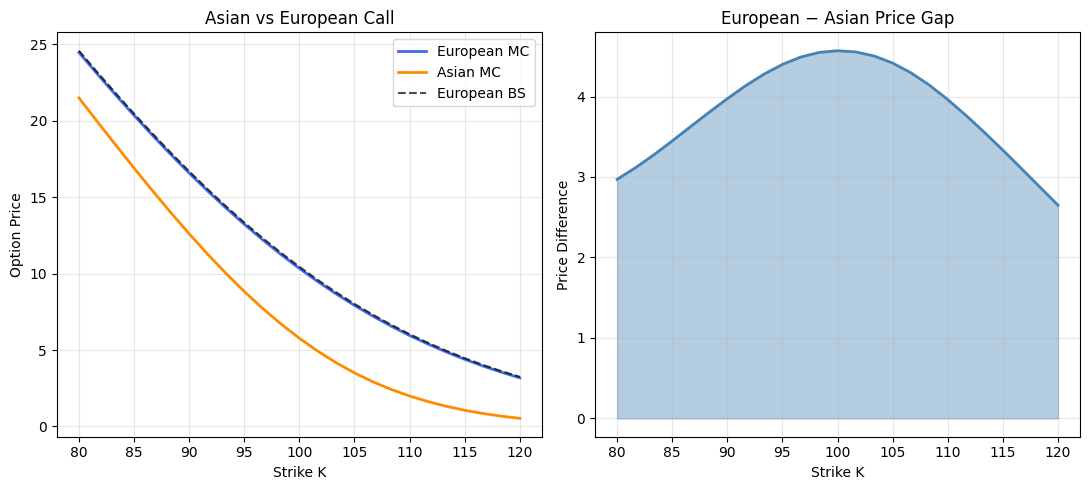

In [5]:
strikes = np.linspace(80, 120, 25)
asian_prices    = [mc_asian(S, K_i, T, r, sigma, n_sims=50_000, seed=7) for K_i in strikes]
european_prices = [mc_european(S, K_i, T, r, sigma, n_sims=50_000, seed=7) for K_i in strikes]
bs_prices       = [bs_price(S, K_i, T, r, sigma, 'call') for K_i in strikes]

fig, axes = plt.subplots(1, 2)
axes[0].plot(strikes, european_prices, 'royalblue', lw=2, label='European MC')
axes[0].plot(strikes, asian_prices,    'darkorange', lw=2, label='Asian MC')
axes[0].plot(strikes, bs_prices,       'k--', lw=1.5, alpha=0.7, label='European BS')
axes[0].set_xlabel('Strike K')
axes[0].set_ylabel('Option Price')
axes[0].set_title('Asian vs European Call')
axes[0].legend()

diff = np.array(european_prices) - np.array(asian_prices)
axes[1].fill_between(strikes, 0, diff, alpha=0.4, color='steelblue')
axes[1].plot(strikes, diff, 'steelblue', lw=2)
axes[1].set_xlabel('Strike K')
axes[1].set_ylabel('Price Difference')
axes[1].set_title('European − Asian Price Gap')
plt.tight_layout()
plt.show()

## Step 5 — Down-and-Out Barrier Call: Price vs Barrier Level

A **down-and-out call** is knocked out (pays 0) if the stock ever touches the barrier H from above. As H rises toward the current spot S₀, the probability of knock-out increases, so the option price falls to 0. For very low barriers, the option behaves like a vanilla call.

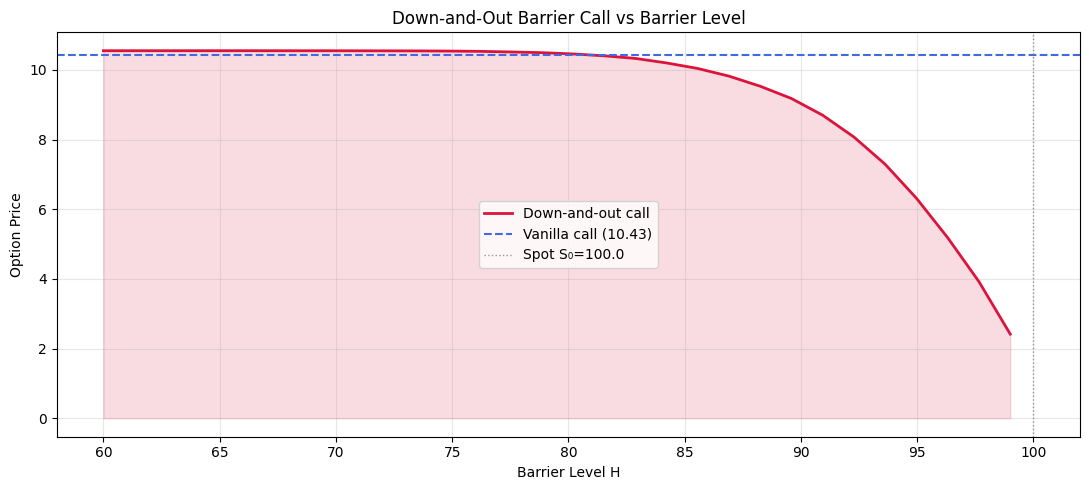

Barrier at H=80: 10.4105
Vanilla call:    10.4294


In [6]:
barriers = np.linspace(60, 99, 30)
barrier_prices = [mc_barrier_down_out(S, K, T, r, sigma, H, n_sims=50_000, seed=11) for H in barriers]
vanilla_price  = mc_european(S, K, T, r, sigma, n_sims=50_000, seed=11)

fig, ax = plt.subplots()
ax.plot(barriers, barrier_prices, 'crimson', lw=2, label='Down-and-out call')
ax.axhline(vanilla_price, color='royalblue', lw=1.5, linestyle='--', label=f'Vanilla call ({vanilla_price:.2f})')
ax.axvline(S, color='gray', lw=1, linestyle=':', alpha=0.8, label=f'Spot S₀={S}')
ax.fill_between(barriers, 0, barrier_prices, alpha=0.15, color='crimson')
ax.set_xlabel('Barrier Level H')
ax.set_ylabel('Option Price')
ax.set_title('Down-and-Out Barrier Call vs Barrier Level')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Barrier at H=80: {mc_barrier_down_out(S, K, T, r, sigma, 80, n_sims=100_000, seed=11):.4f}')
print(f'Vanilla call:    {vanilla_price:.4f}')